# Experiment 2 Analysis: Repair Quality vs. Epsilon

This notebook provides a detailed analysis of the repair process for synthetic datasets generated with varying levels of Differential Privacy (Epsilon). We compare three Vertex Cover (VC) based repair algorithms:
1. **Vanilla VC**: Max-degree based vertex selection.
2. **Classic VC**: Random edge-based vertex selection.
3. **Weighted VC**: Frequency-weighted selection (optimized for marginal preservation).

## Objectives
- Analyze the relationship between **Epsilon** and **Violation Count**.
- Compare the **Deletion Ratio** across repair algorithms.
- Evaluate the **Utility Trade-off** (ML Accuracy, TVD, and Marginals Error) after repair.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Set plotting style
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.figsize"] = (12, 6)

# Load aggregated results
summary_path = "../output/experiment_2_summary.csv"
df = pd.read_csv(summary_path)

# Preprocessing: Average across seeds for cleaner trends
avg_df = df.groupby(["dataset", "synthesizer", "epsilon", "repair_algorithm"]).mean(numeric_only=True).reset_index()

print(f"Loaded {len(df)} individual results.")
print(f"Aggregated into {len(avg_df)} unique configurations.")
avg_df.head()

Loaded 846 individual results.
Aggregated into 171 unique configurations.


,dataset,synthesizer,epsilon,repair_algorithm,job_id,seed,deletion_ratio,marginals_error_synthetic,marginals_error_repaired,tvd_synthetic,tvd_repaired,violations_synthetic,violations_repaired,loss_synthetic,loss_repaired,ml_acc_synthetic,ml_acc_repaired
0,adult,aim,0.3,vanilla_vc,52.0,208.4,0.078440,0.794580,0.802351,0.046252,0.051786,34456127.00,0.0,-0.005550,0.034640,0.835080,0.835934
1,adult,aim,0.3,weighted_vc,48.0,42.0,0.082240,0.811423,0.782747,0.046197,0.052036,35396875.00,0.0,-0.005370,0.036443,0.835183,0.834746
2,adult,aim,0.4,vanilla_vc,67.0,208.4,0.055016,0.368048,0.367632,0.043487,0.046187,24998018.60,0.0,-0.006779,0.021414,0.832351,0.832757
3,adult,aim,0.4,weighted_vc,67.5,160.5,0.061425,0.366324,0.334776,0.043475,0.046531,24972921.25,0.0,-0.006778,0.024132,0.832199,0.832569
4,adult,aim,0.5,classic_vc,83.0,208.4,0.093912,0.337400,0.338391,0.036671,0.043940,26237053.00,0.0,-0.006613,0.041507,0.836239,0.836402


## 1. The Violation Explosion
Lower epsilon (higher noise) leads to more violations. This chart shows the initial state of the synthetic data before repair.

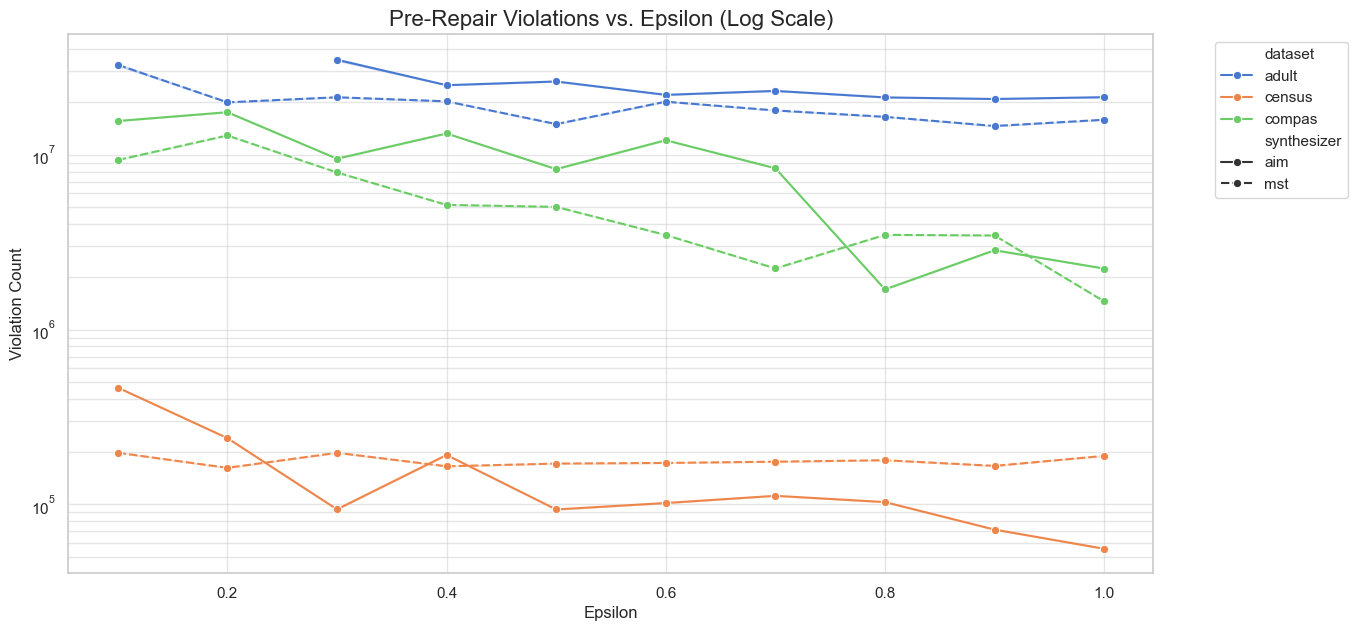

In [ ]:
plt.figure(figsize=(14, 7))
sns.lineplot(data=avg_df, x="epsilon", y="violations_synthetic", hue="dataset", style="synthesizer", marker="o")
plt.yscale("log")
plt.title("Pre-Repair Violations vs. Epsilon (Log Scale)", fontsize=16)
plt.ylabel("Violation Count", fontsize=12)
plt.xlabel("Epsilon", fontsize=12)
plt.grid(True, which="both", ls="-", alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 2. Global Trends: Dataset-Centric Performance

Each metric is presented as a grid of plots (one per dataset).
- **Color**: Represents the **Repair Algorithm** (Vanilla, Classic, Weighted).
- **Marker**: Represents the **Generation Algorithm** (AIM vs MST).

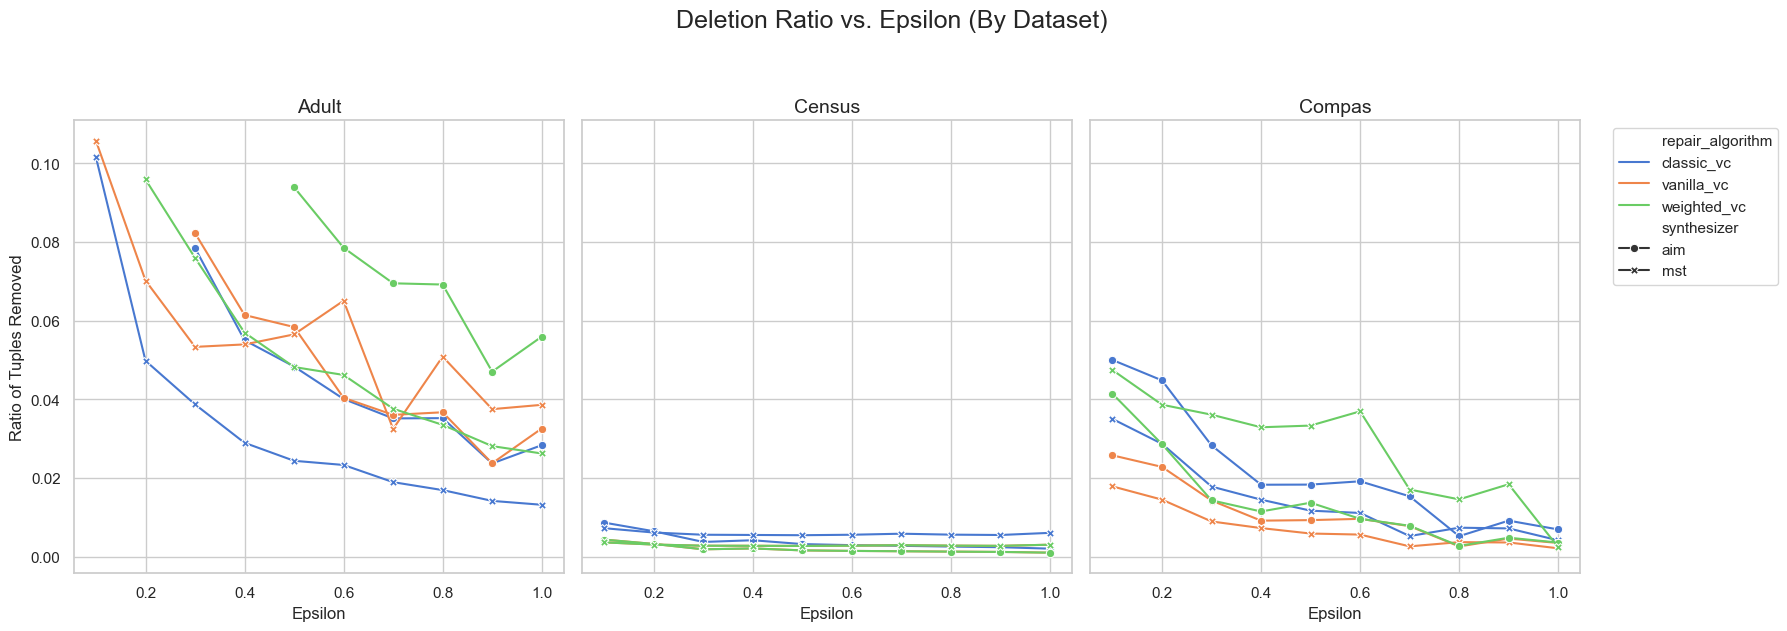

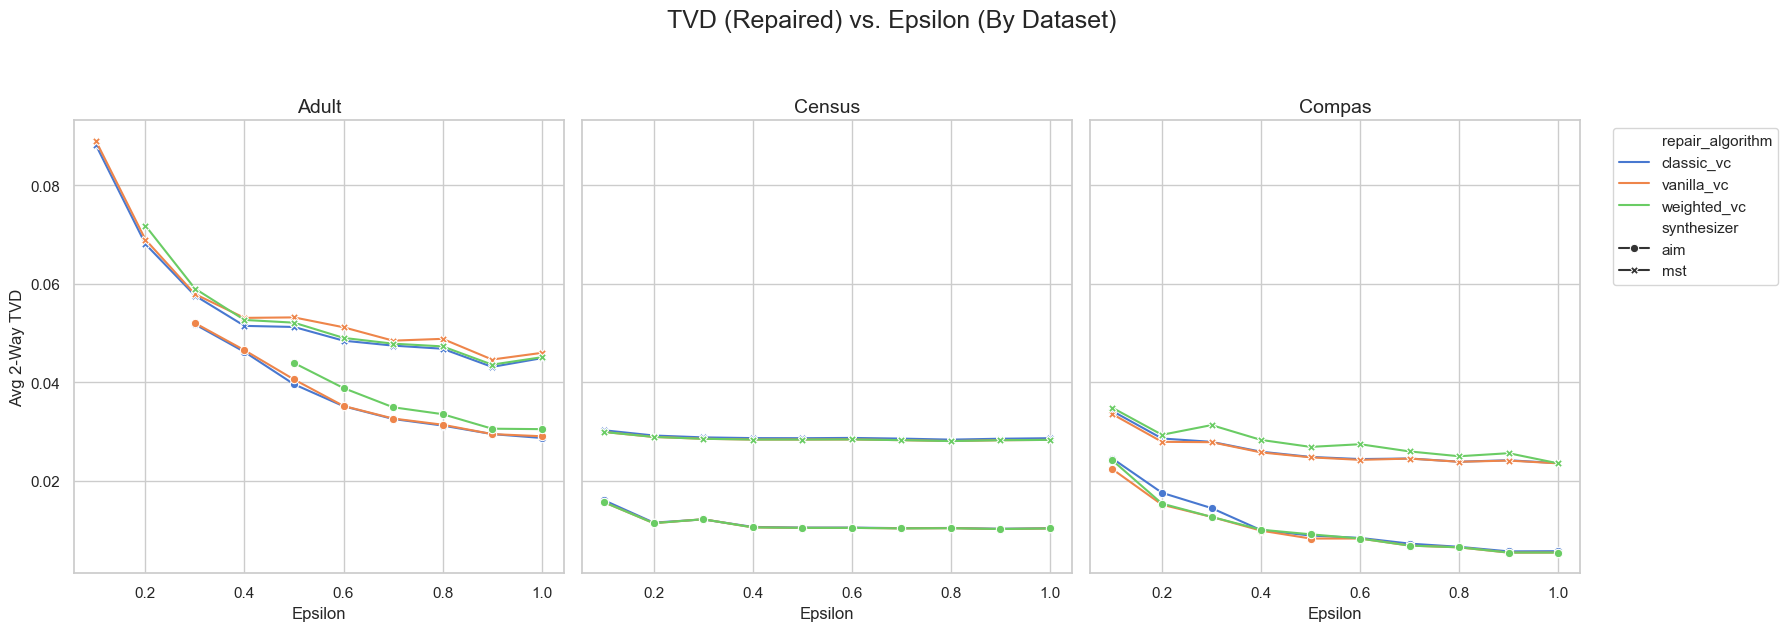

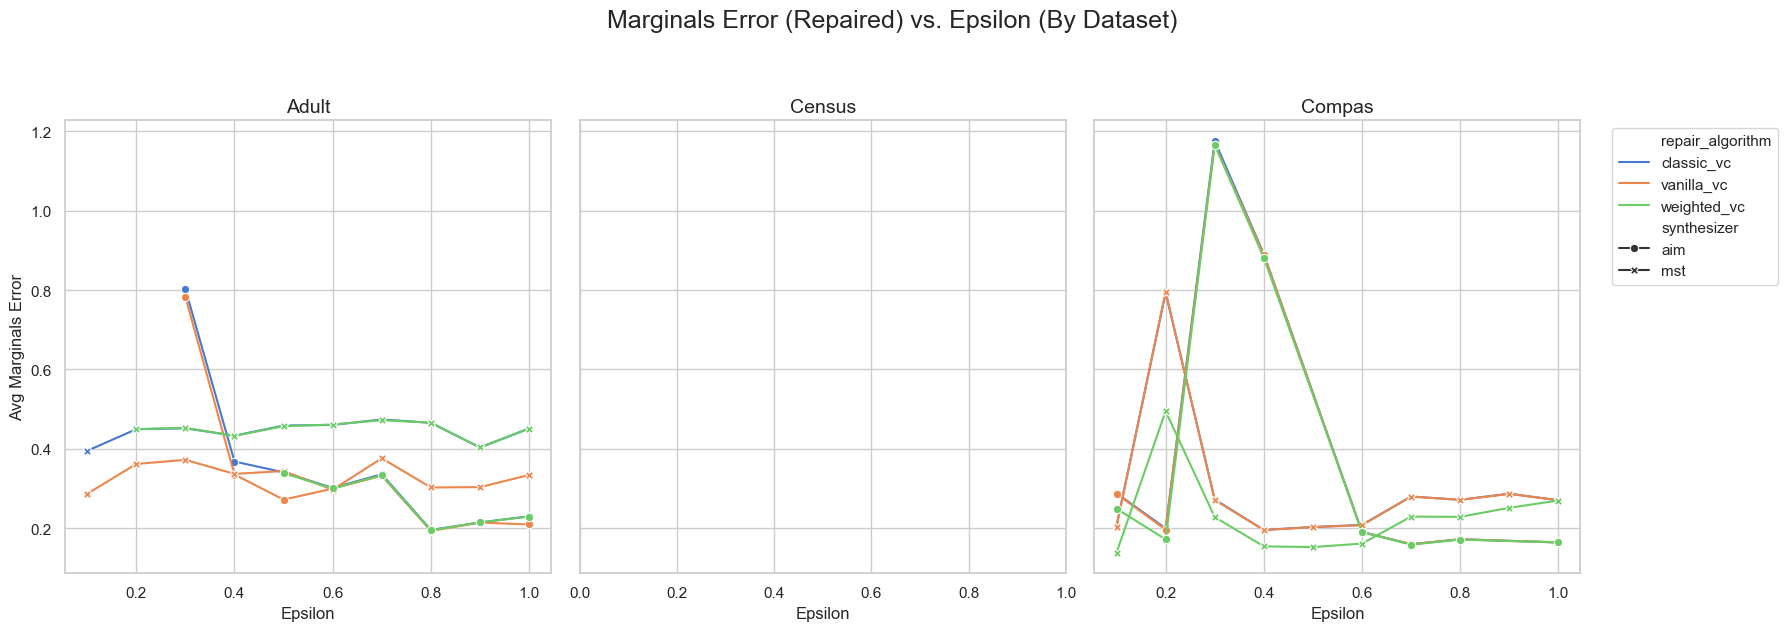

In [ ]:
def plot_dataset_centric_metric(df, metric_col, title, ylabel):
    datasets = sorted(df["dataset"].unique())
    n_datasets = len(datasets)
    
    fig, axes = plt.subplots(1, n_datasets, figsize=(6 * n_datasets, 6), sharey=True)
    if n_datasets == 1: axes = [axes]
    
    for i, ds in enumerate(datasets):
        ds_df = df[df["dataset"] == ds]
        sns.lineplot(
            ax=axes[i], 
            data=ds_df, 
            x="epsilon", 
            y=metric_col, 
            hue="repair_algorithm", 
            style="synthesizer", 
            markers=True, 
            dashes=False
        )
        axes[i].set_title(f"{ds.capitalize()}", fontsize=14)
        axes[i].set_xlabel("Epsilon")
        if i == 0: axes[i].set_ylabel(ylabel)
        
        # Clean up legend
        if i != n_datasets - 1: 
            axes[i].get_legend().remove()
        else:
            axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')
            
plt.suptitle(title, fontsize=18, y=1.05)
    plt.tight_layout()
    plt.show()

# 1. Deletion Ratio
plot_dataset_centric_metric(avg_df, "deletion_ratio", "Deletion Ratio vs. Epsilon (By Dataset)", "Ratio of Tuples Removed")

# 2. TVD (Total Variation Distance)
plot_dataset_centric_metric(avg_df, "tvd_repaired", "TVD (Repaired) vs. Epsilon (By Dataset)", "Avg 2-Way TVD")

# 3. Marginals Error (Relative)
plot_dataset_centric_metric(avg_df, "marginals_error_repaired", "Relative Marginals Error vs. Epsilon", "Avg Relative Error")

# 4. Marginal Loss (Absolute)
plot_dataset_centric_metric(avg_df, "loss_marginal_repaired", "Marginal Loss (Absolute) vs. Epsilon", "Mean Absolute Error (MAE)")

## 3. Utility Impact: ML Accuracy
Does the repair process preserve the predictive power of the dataset?

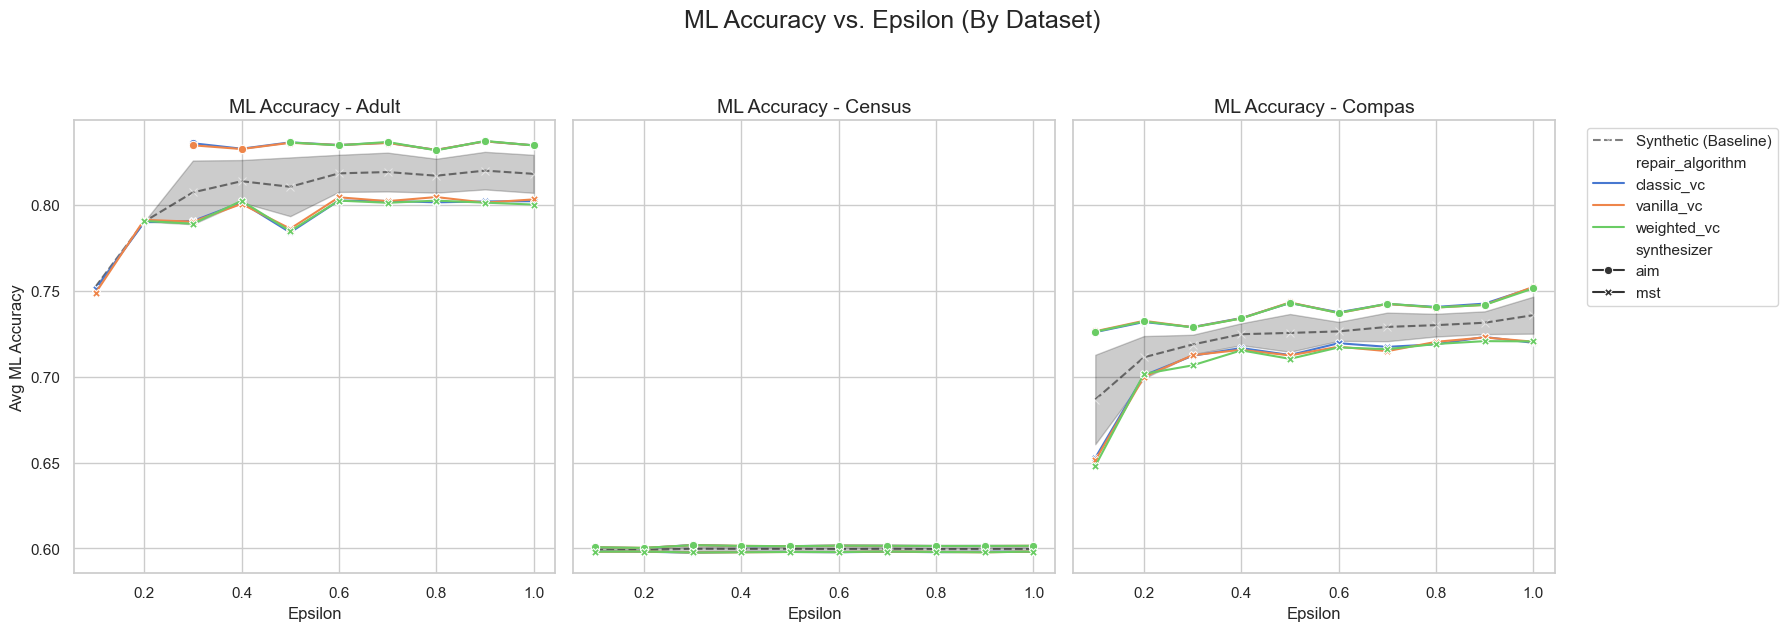

In [ ]:
datasets = sorted(avg_df["dataset"].unique())
fig, axes = plt.subplots(1, len(datasets), figsize=(6 * len(datasets), 6), sharey=True)
if len(datasets) == 1: axes = [axes]

for i, ds in enumerate(datasets):
    ds_df = avg_df[avg_df["dataset"] == ds]
    # We include the baseline (synthetic pre-repair) as a reference
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="ml_acc_synthetic", label="Synthetic (Baseline)", color="black", linestyle="--", marker="x", alpha=0.5)
    sns.lineplot(ax=axes[i], data=ds_df, x="epsilon", y="ml_acc_repaired", hue="repair_algorithm", style="synthesizer", markers=True, dashes=False)
    axes[i].set_title(f"ML Accuracy - {ds.capitalize()}", fontsize=14)
    axes[i].set_xlabel("Epsilon")
    if i == 0: axes[i].set_ylabel("Avg ML Accuracy")
    
    if i != len(datasets) - 1:
        axes[i].get_legend().remove()
    else:
        axes[i].legend(bbox_to_anchor=(1.05, 1), loc='upper left')

plt.suptitle("ML Accuracy vs. Epsilon (By Dataset)", fontsize=18, y=1.05)
plt.tight_layout()
plt.show()

## 4. Marginals Preservation: Boxplot Comparison
Distribution of relative improvement in marginals across all epsilon/seed configurations.

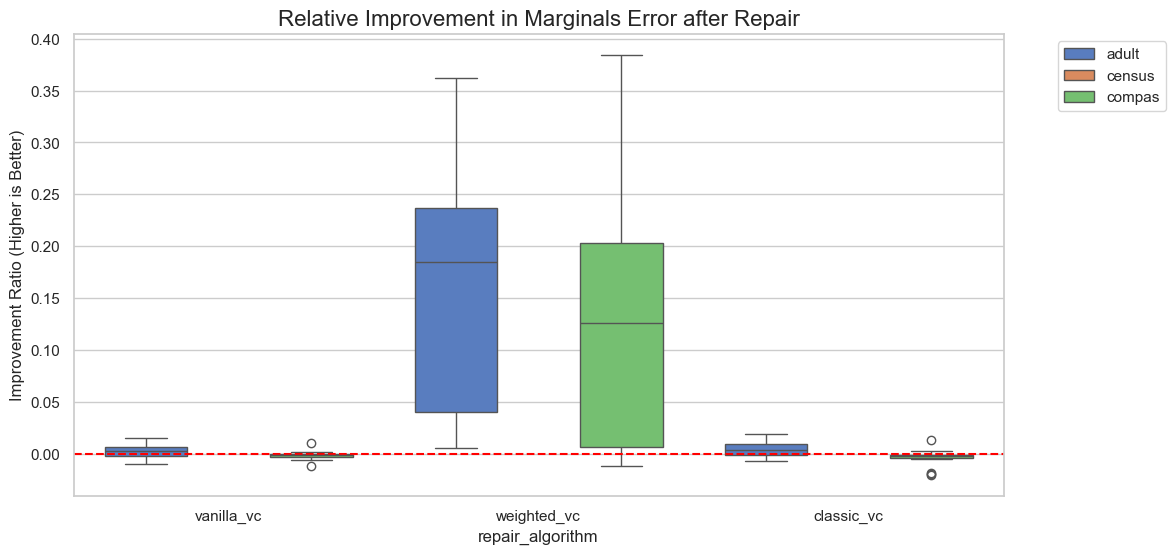

In [ ]:
avg_df["marginals_improvement"] = (avg_df["marginals_error_synthetic"] - avg_df["marginals_error_repaired"]) / avg_df["marginals_error_synthetic"]

plt.figure(figsize=(12, 6))
sns.boxplot(data=avg_df, x="repair_algorithm", y="marginals_improvement", hue="dataset")
plt.title("Relative Improvement in Marginals Error after Repair", fontsize=16)
plt.ylabel("Improvement Ratio (Higher is Better)")
plt.axhline(0, color='red', linestyle='--')
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

## 5. Statistical Summary Table

In [ ]:
stats = df.groupby(["dataset", "repair_algorithm"])[["deletion_ratio", "ml_acc_repaired", "tvd_repaired"]].agg(["mean", "std"])
stats.style.background_gradient(cmap="YlGn")